# Telecom network metrics — submission-ready PySpark demo

This notebook executes the same shared modules used by `spark-submit`. It demonstrates the complete Bronze → Silver → Gold → Monitoring flow, SHA-256 manifest lineage, cross-midnight handling, reconciliation, robust anomaly detection and explainable quarantine rules.

Expected sample result: **100 Bronze rows, 100 Silver rows, 74 hourly Gold groups, 8 daily Gold groups, 4 warning-only rows and 0 reconciliation mismatches**.

## 1. Locate the project and start a controlled local Spark session

In [1]:
import os
import sys
import tempfile
from pathlib import Path

python_exe = sys.executable
os.environ['PYSPARK_PYTHON'] = python_exe
os.environ['PYSPARK_DRIVER_PYTHON'] = python_exe
os.environ.setdefault('SPARK_LOCAL_IP', '127.0.0.1')
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'network-metrics-matplotlib'))

if os.name == 'nt':
    hadoop_home = Path(os.environ.get('HADOOP_HOME', Path.home() / 'hadoop'))
    os.environ['HADOOP_HOME'] = str(hadoop_home)
    os.environ['PATH'] = str(hadoop_home / 'bin') + os.pathsep + os.environ['PATH']
    hadoop_status = 'configured' if (hadoop_home / 'bin').exists() else 'not found; run scripts/check_environment.ps1'
else:
    hadoop_status = 'not required'

print(f'Python: {sys.version.split()[0]}')
print('Driver/worker Python aligned:', os.environ['PYSPARK_PYTHON'] == sys.executable)
print('Windows Hadoop compatibility:', hadoop_status)

Python: 3.11.15
Driver/worker Python aligned: True
Windows Hadoop compatibility: not required


In [2]:
from datetime import date, datetime, timedelta, timezone
from uuid import uuid4

from IPython.display import display

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Open this notebook from inside the project folder.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pyspark.sql import SparkSession, functions as F
from network_metrics.anomaly import build_hourly_anomalies
from network_metrics.config import PipelineConfig
from network_metrics.filesystem import validate_source_file
from network_metrics.jobs import run_bronze, run_silver, run_gold_hourly, run_gold_daily, run_monitoring
from network_metrics.main import execute_stage
from network_metrics.manifest import successful_manifest_entry, write_manifest_event
from network_metrics.paths import PipelinePaths
from network_metrics.quality import reconciliation_mismatch_count
from network_metrics.transforms import build_silver_candidate

spark = (
    SparkSession.builder.master('local[2]')
    .appName('network-metrics-notebook-demo')
    .config('spark.sql.session.timeZone', 'UTC')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.driver.bindAddress', '127.0.0.1')
    .config('spark.driver.host', '127.0.0.1')
    .config('spark.ui.enabled', 'false')
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print(f'Project root detected: {PROJECT_ROOT.name}')
print(f'Spark: {spark.version}')

Project root detected: telecom-network-metrics-pipeline-final
Spark: 3.5.0


## 2. Execute every stage with source identity and manifest lineage

In [3]:
run_id = f"notebook-{datetime.now(timezone.utc):%Y%m%dT%H%M%SZ}-{uuid4().hex[:6]}"
config = PipelineConfig.from_json(PROJECT_ROOT / 'config' / 'pipeline.example.json').with_overrides(
    input_path=str(PROJECT_ROOT / 'sample_data'),
    output_root=str(PROJECT_ROOT / 'output' / 'demo' / run_id),
    processing_date='2025-07-23',
)
paths = PipelinePaths(config.input_path, config.output_root)
source_info = validate_source_file(spark, config.input_path, config.processing_date)

write_manifest_event(
    spark, paths.processing_manifest,
    source_path=source_info['source_path'], source_sha256=source_info['source_sha256'],
    processing_date=config.processing_date, run_id=run_id, status='RUNNING',
    details={'filename': source_info['filename']},
)

stage_functions = [
    ('bronze', lambda: run_bronze(spark, config=config, pipeline_id='network_metrics_medallion_demo', run_id=run_id, source_info=source_info)),
    ('silver', lambda: run_silver(spark, config=config, run_id=run_id)),
    ('gold-hourly', lambda: run_gold_hourly(spark, config=config, run_id=run_id)),
    ('gold-daily', lambda: run_gold_daily(spark, config=config, run_id=run_id)),
    ('monitoring', lambda: run_monitoring(spark, config=config, run_id=run_id)),
]
results = {
    name: execute_stage(spark, config, run_id, name, function)
    for name, function in stage_functions
}
write_manifest_event(
    spark, paths.processing_manifest,
    source_path=source_info['source_path'], source_sha256=source_info['source_sha256'],
    processing_date=config.processing_date, run_id=run_id, status='SUCCESS',
    details=results,
)
reviewer_results = {
    stage: {key: value for key, value in details.items() if key not in {'source_path', 'modification_time_ms', 'source_sha256'}}
    for stage, details in results.items()
}
display(reviewer_results)
print('Source SHA-256:', source_info['source_sha256'])

{'bronze': {'stage': 'bronze', 'rows': 100, 'filename': 'network_metrics_20250723.csv', 'size_bytes': 3344}, 'silver': {'stage': 'silver', 'affected_dates': ['2025-07-24', '2025-07-23'], 'published_rows': 100, 'input_rows': 100, 'invalid_rows': 0, 'warning_rows': 4, 'date_mismatch_rows': 4, 'invalid_rate': 0.0}, 'gold-hourly': {'stage': 'gold_hourly', 'rows': 74, 'affected_dates': ['2025-07-24', '2025-07-23']}, 'gold-daily': {'stage': 'gold_daily', 'rows': 8, 'affected_dates': ['2025-07-24', '2025-07-23']}, 'monitoring': {'stage': 'monitoring', 'status': 'PASS', 'affected_dates': ['2025-07-24', '2025-07-23'], 'hourly_mismatches': 0, 'daily_mismatches': 0, 'anomaly_status': 'INSUFFICIENT_HISTORY', 'anomaly_rows': 0, 'baseline_eligible_rows': 0}}
Source SHA-256: f61478d56a3851821d4f4980955d6aa1f6316129c79a89d5b51990dca7e5f9c2


## 3. Inspect Bronze lineage and validated Silver events

In [4]:
bronze = spark.read.parquet(paths.bronze).filter(F.col('_run_id') == run_id)
silver = spark.read.parquet(paths.silver)

print(f'Bronze rows in this run: {bronze.count()}')
bronze_preview = bronze.orderBy('timestamp').select(
    'tower_id', 'region', 'timestamp', 'signal_strength', 'data_volume_mb',
    '_file_date', '_run_id', '_quality_status' if '_quality_status' in bronze.columns else '_stage_id'
).limit(8).toPandas()
display(bronze_preview)

print(f'Silver rows across affected dates: {silver.count()}')
display(
    silver.orderBy('event_timestamp_utc')
    .select('tower_id', 'region', 'event_timestamp_utc', 'event_hour_utc',
            'signal_strength', 'data_volume_mb', '_quality_status')
    .limit(8).toPandas()
)

Bronze rows in this run: 100
   tower_id   region  ...                           _run_id  _stage_id
0       102    North  ...  notebook-20260718T122710Z-b1c816     bronze
1       103    North  ...  notebook-20260718T122710Z-b1c816     bronze
2       102  Central  ...  notebook-20260718T122710Z-b1c816     bronze
3       104    South  ...  notebook-20260718T122710Z-b1c816     bronze
4       104  Central  ...  notebook-20260718T122710Z-b1c816     bronze
5       105    North  ...  notebook-20260718T122710Z-b1c816     bronze
6       107     East  ...  notebook-20260718T122710Z-b1c816     bronze
7       106    North  ...  notebook-20260718T122710Z-b1c816     bronze

[8 rows x 8 columns]
Silver rows across affected dates: 100
   tower_id   region  ... data_volume_mb _quality_status
0       102    North  ...           99.0           VALID
1       103    North  ...          228.4           VALID
2       102  Central  ...           56.0           VALID
3       104    South  ...           55.3   

## 4. Explain the cross-midnight warning

In [5]:
warning_rows = silver.filter(F.size('_quality_warnings') > 0)
print(f'Warning-only rows: {warning_rows.count()}')
display(
    warning_rows.select(
        'tower_id', 'region', 'event_timestamp_utc', '_file_date',
        'event_date', '_quality_warnings'
    ).orderBy('event_timestamp_utc').toPandas()
)

Warning-only rows: 4
   tower_id   region  ...  event_date                        _quality_warnings
0       105     East  ...  2025-07-24  [event_date_differs_from_filename_date]
1       106    North  ...  2025-07-24  [event_date_differs_from_filename_date]
2       103  Central  ...  2025-07-24  [event_date_differs_from_filename_date]
3       102  Central  ...  2025-07-24  [event_date_differs_from_filename_date]

[4 rows x 6 columns]


## 5. Inspect required Gold reports

Hourly Gold groups: 74
Daily Gold groups: 8
     region      event_hour_utc  ...     _updated_timestamp_utc  event_date
0   Central 2025-07-23 00:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
1     North 2025-07-23 00:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
2     South 2025-07-23 00:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
3   Central 2025-07-23 01:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
4      East 2025-07-23 01:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
5     North 2025-07-23 01:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
6   Central 2025-07-23 02:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
7      East 2025-07-23 03:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
8     North 2025-07-23 03:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
9     South 2025-07-23 03:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
10     West 2025-07-23 03:00:00  ... 2026-07-18 12:27:18.165167  2025-07-23
11     East 2025-07-23 04:00:00  ... 2026-07

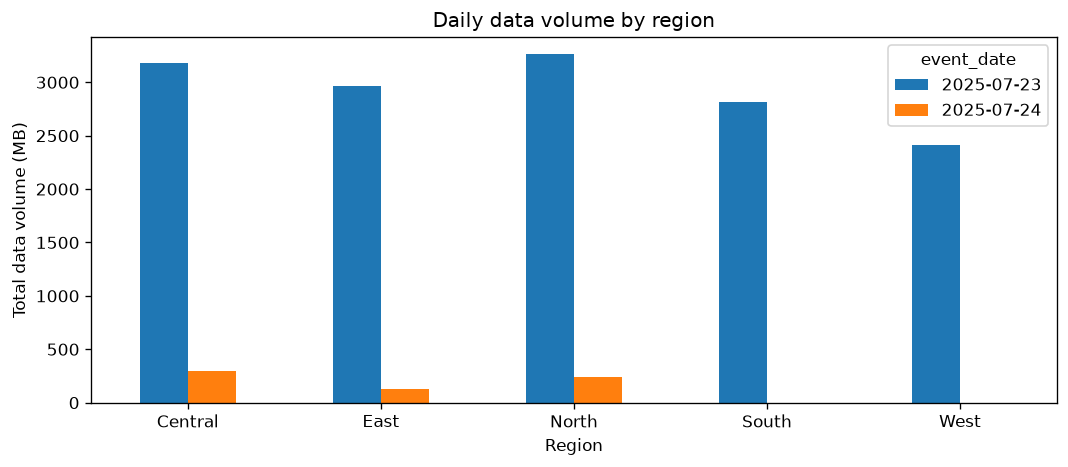

In [6]:
hourly = spark.read.parquet(paths.gold_hourly)
daily = spark.read.parquet(paths.gold_daily)

print(f'Hourly Gold groups: {hourly.count()}')
print(f'Daily Gold groups: {daily.count()}')
display(hourly.orderBy('event_hour_utc', 'region').limit(20).toPandas())
daily_pd = daily.orderBy('event_date', 'region').toPandas()
display(daily_pd)

from matplotlib import pyplot as plt
chart_data = daily_pd.pivot(index='region', columns='event_date', values='total_data_volume_mb')
ax = chart_data.plot.bar(
    title='Daily data volume by region', ylabel='Total data volume (MB)',
    xlabel='Region', figsize=(9, 4), rot=0,
)
plt.tight_layout()
plt.show()

## 6. Verify reconciliation, anomaly output and the processing manifest

In [7]:
quality_logs = spark.read.parquet(paths.quality_logs).filter(F.col('run_id') == run_id)
run_logs = spark.read.parquet(paths.pipeline_logs).filter(F.col('run_id') == run_id)
anomalies = spark.read.parquet(paths.hourly_anomalies)
manifest = spark.read.parquet(paths.processing_manifest).filter(F.col('run_id') == run_id)

display(quality_logs.orderBy('check_timestamp_utc').toPandas())
display(run_logs.select('stage', 'status', 'started_timestamp_utc', 'completed_timestamp_utc').orderBy('started_timestamp_utc').toPandas())
display(manifest.select('processing_date', 'run_id', 'status', 'event_timestamp_utc').orderBy('event_timestamp_utc').toPandas())
display(anomalies.select('region', 'event_hour_utc', 'baseline_count', 'anomaly_status', 'anomaly_reasons').orderBy('event_hour_utc', 'region').limit(12).toPandas())

hourly_mismatches = reconciliation_mismatch_count(silver, hourly, group_columns=('region', 'event_hour_utc'))
daily_mismatches = reconciliation_mismatch_count(silver, daily)
assert hourly_mismatches == 0 and daily_mismatches == 0
assert successful_manifest_entry(spark, paths.processing_manifest, source_info['source_sha256'])['run_id'] == run_id
print('Silver-to-hourly-Gold reconciliation: PASS')
print('Silver-to-daily-Gold reconciliation: PASS')
print('Identical source manifest lookup: SUCCESS — a second complete submission would be skipped')

                             run_id  ...        check_timestamp_utc
0  notebook-20260718T122710Z-b1c816  ... 2026-07-18 12:27:16.739142
1  notebook-20260718T122710Z-b1c816  ... 2026-07-18 12:27:21.485463
2  notebook-20260718T122710Z-b1c816  ... 2026-07-18 12:27:21.485463
3  notebook-20260718T122710Z-b1c816  ... 2026-07-18 12:27:21.485463

[4 rows x 9 columns]
         stage   status      started_timestamp_utc    completed_timestamp_utc
0       bronze  SUCCESS 2026-07-18 12:27:14.542812 2026-07-18 12:27:15.393234
1       silver  SUCCESS 2026-07-18 12:27:15.572870 2026-07-18 12:27:17.714153
2  gold-hourly  SUCCESS 2026-07-18 12:27:17.841123 2026-07-18 12:27:18.591965
3   gold-daily  SUCCESS 2026-07-18 12:27:18.713717 2026-07-18 12:27:19.343037
4   monitoring  SUCCESS 2026-07-18 12:27:19.459518 2026-07-18 12:27:21.607149
  processing_date  ...        event_timestamp_utc
0      2025-07-23  ... 2026-07-18 12:27:13.389588
1      2025-07-23  ... 2026-07-18 12:27:21.729917

[2 rows x 4 columns

## 7. Demonstrate the implemented median/MAD anomaly detector

In [8]:
current_date = date(2025, 8, 1)
history_rows = []
for offset in range(8, 0, -1):
    historical_date = current_date - timedelta(days=offset)
    history_rows.append(('North', datetime.combine(historical_date, datetime.min.time()), historical_date, 100.0, -80.0, 20, 10))
history_rows.append(('North', datetime.combine(current_date, datetime.min.time()), current_date, 10.0, -100.0, 2, 2))
synthetic_hourly = spark.createDataFrame(
    history_rows,
    'region string, event_hour_utc timestamp, event_date date, total_data_volume_mb double, average_signal_strength double, record_count long, distinct_tower_count long'
)
synthetic_anomaly = build_hourly_anomalies(
    synthetic_hourly, [current_date], lookback_days=28, min_history=7, mad_threshold=6.0
)
display(synthetic_anomaly.select(
    'region', 'event_hour_utc', 'baseline_count', 'volume_robust_z',
    'signal_robust_z', 'anomaly_status', 'anomaly_reasons'
).toPandas())
assert synthetic_anomaly.first().anomaly_status == 'ANOMALY'

  region  ...                                    anomaly_reasons
0  North  ...  [data_volume_deviation, signal_strength_degrad...

[1 rows x 7 columns]


## 8. Demonstrate explainable invalid-row handling

In [9]:
invalid_demo = (
    bronze.limit(1)
    .withColumn('tower_id', F.lit(-1))
    .withColumn('region', F.lit(''))
    .withColumn('signal_strength', F.lit(-500.0))
    .withColumn('data_volume_mb', F.lit(-1.0))
)
invalid_result = build_silver_candidate(invalid_demo, check_duplicates=False)
display(invalid_result.select(
    'tower_id', 'region', 'signal_strength', 'data_volume_mb',
    '_quality_status', '_quality_errors'
).toPandas())
assert invalid_result.first()._quality_status == 'INVALID'

   tower_id  ...                                    _quality_errors
0        -1  ...  [tower_id_non_positive, region_null_or_blank, ...

[1 rows x 6 columns]


## 9. Finish

In [10]:
spark.stop()
print(f'Demo completed successfully. Run ID: {run_id}')

Demo completed successfully. Run ID: notebook-20260718T122710Z-b1c816
